Importer les bibliothèques


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


Charger les datasets

In [2]:
#Ici on lit les fichiers CSV
interactions = pd.read_csv("../data/raw/interactions.csv")
products=pd.read_csv("../data/raw/produits.csv",encoding='latin-1')
#affichier les premiers lignes de datasets
products.head()
#interactions.head()



,id,barcode,name,price,category_name,brand,supplier,expiration_date,allergens,Ingredients vary by product,tags
0,1,2501000001,Potatoes bulk,170,Fruits & Vegetables,Fresh Day,Fresh Day Ltd,6/4/2026 22:44,[],Fresh products. No preservatives,"[""fresh"". ""vegetables""]"
1,2,2501000002,Yellow onions bulk,145,Fruits & Vegetables,Fresh Day,Fresh Day Ltd,9/14/2026 3:01,[],Fresh products. No preservatives,"[""fresh"". ""vegetables""]"
2,3,2501000003,Carrots bulk,175,Fruits & Vegetables,Fresh Day,Fresh Day Ltd,7/11/2026 22:58,[],Fresh products. No preservatives,"[""fresh"". ""vegetables""]"
3,4,2501000004,Zucchini bulk,160,Fruits & Vegetables,Fresh Day,Fresh Day Ltd,7/8/2026 23:35,[],Fresh products. No preservatives,"[""fresh"". ""vegetables""]"
4,5,2501000005,Green peppers bulk,60,Fruits & Vegetables,Fresh Day,Fresh Day Ltd,11/29/2026 16:23,[],Fresh products. No preservatives,"[""fresh"". ""vegetables""]"


Analyse de la forme des données

In [3]:
df_p=products.copy()
df_i=interactions.copy()

In [4]:
#nombre de lignes et colonnes
df_p.shape
df_i.shape

(2200, 18)

In [5]:
#type de variables
df_p.dtypes
df_i.dtypes

id                  int64
user_id               str
session_id            str
timestamp             str
health_profile        str
product_id          int64
product_name          str
barcode             int64
category              str
ingredients           str
season                str
action                str
dlc_days            int64
hour                int64
cart_id           float64
order_id          float64
quantity          float64
price             float64
dtype: object

In [6]:
#variables manquantes
products.isnull().sum() 
interactions.isnull().sum()

id                   0
user_id              0
session_id           0
timestamp            0
health_profile     290
product_id           0
product_name         0
barcode              0
category             0
ingredients          0
season               0
action               0
dlc_days             0
hour                 0
cart_id           1571
order_id          2031
quantity          1571
price               28
dtype: int64

Analyse du fond des données

In [7]:
#affichage les colonnes pour cemprendre les variables
df_p.columns
#df_i.columns

Index(['id', 'barcode', 'name', 'price', 'category_name', 'brand', 'supplier',
       'expiration_date', 'allergens', 'Ingredients vary by product', 'tags'],
      dtype='str')

In [8]:
# Calcul du action_score 
action_weights = {'search':1, 'view':2, 'click':2,
                  'add_to_cart':3, 'purchase':4}
interactions['action_score'] = interactions['action'].map(action_weights)

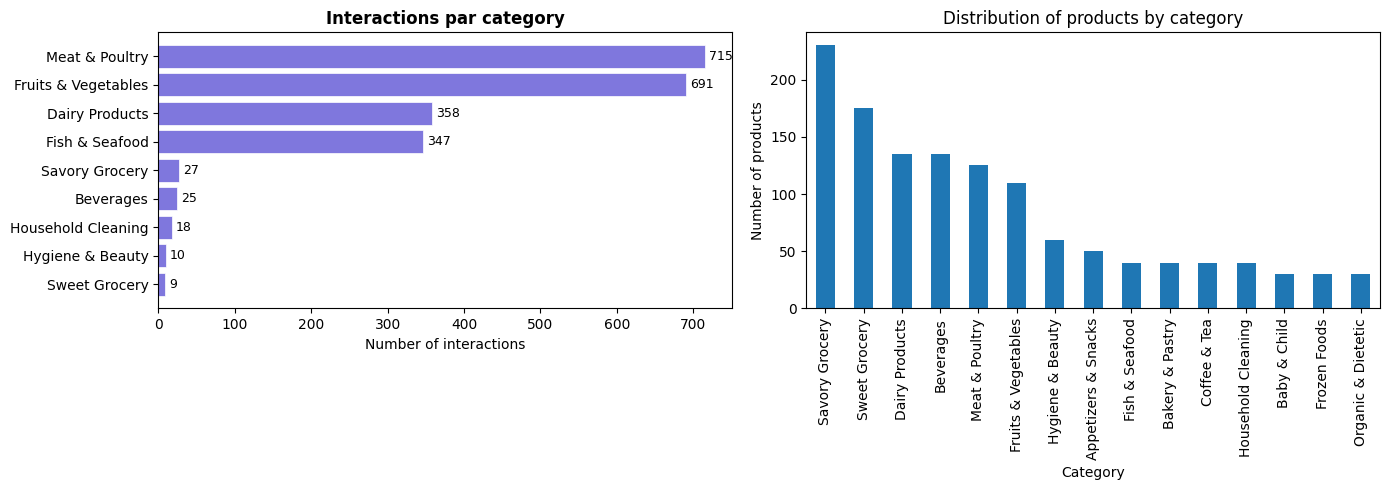

In [9]:
#ANALYSE DES CATEGORIES
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Catégories dans les interactions (volumes réels d'utilisation)
cat_int = interactions['category'].value_counts()
axes[0].barh(cat_int.index[::-1], cat_int.values[::-1],
             color='#7F77DD', edgecolor='white', linewidth=0.5)
for i, val in enumerate(cat_int.values[::-1]):
    axes[0].text(val + 5, i, str(val), va='center', fontsize=9)
axes[0].set_title('Interactions par category', fontweight='bold')
axes[0].set_xlabel('Number of interactions')

# repertitions des produits par catégorie
products['category_name'].value_counts().plot(kind='bar')

plt.title("Distribution of products by category")
plt.xlabel("Category")
plt.ylabel("Number of products")

plt.tight_layout()
plt.savefig('fig1_categories.png', dpi=150, bbox_inches='tight')
plt.show()



In [10]:
# Produits les plus fréquents dans les interactions
print("Most populer products :")
print(interactions['product_id'].value_counts().head(10))

Most populer products :
product_id
155    17
128    16
60     15
196    15
78     15
246    15
149    14
161    14
121    14
93     14
Name: count, dtype: int64


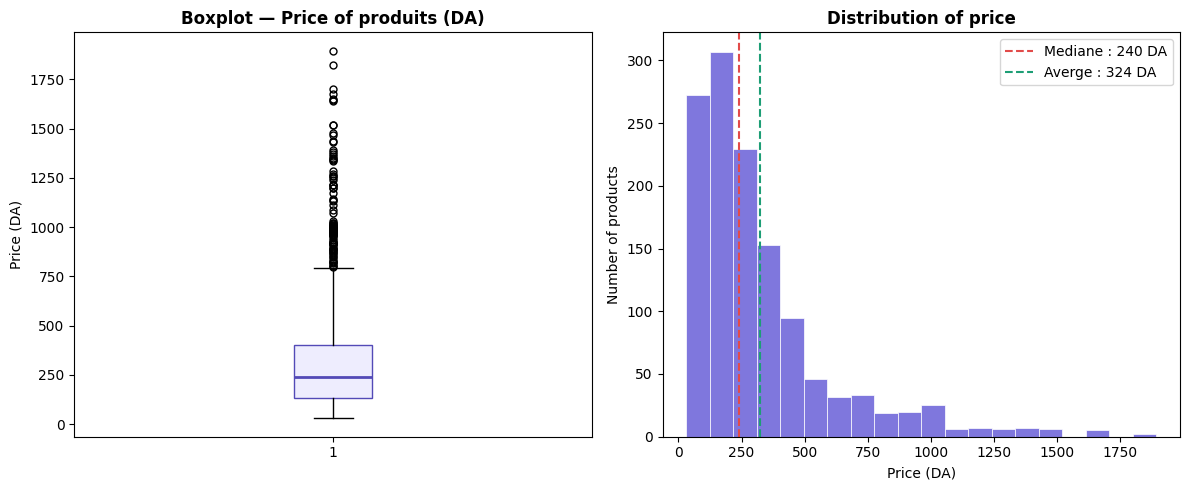


Price — Median:240 DA | Average:324 DA | Q1:135 | Q3:400 | Max:1895.0 DA
Outliers price (95 products) :
                     name  price
               Cuttlefish 1895.0
                    Clams 1820.0
           Diapers size 4 1700.0
Baby food jars vegetables 1675.0
                 Sea bass 1650.0
            Sea bass wild 1645.0
                     Sole 1640.0
              King prawns 1520.0


In [11]:
# Boxplot pour détecter les valeurs aberrantes dans les prix

# -----------------------------------------------------------------------------
# Création d'une figure avec 2 graphiques côte à côte (1 ligne, 2 colonnes)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------------------------------------------------------
# BOXPLOT DES PRIX
# -----------------------------------------------------------------------------
products['price'] = pd.to_numeric(products['price'], errors='coerce')# Création du boxplot des prix avec personnalisation des couleurs
price_data = products['price'].dropna()
axes[0].boxplot(price_data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#EEEDFE', color='#534AB7'),  # couleur de la boîte
                medianprops=dict(color='#534AB7', linewidth=2),        # couleur de la médiane
                flierprops=dict(marker='o', color='#E24B4A', markersize=5))  # points outliers

# Titre du graphique
axes[0].set_title('Boxplot — Price of produits (DA)', fontweight='bold')

# Nom de l’axe Y
axes[0].set_ylabel('Price (DA)')



# -----------------------------------------------------------------------------
# HISTOGRAMME DE DISTRIBUTION DES PRIX
# -----------------------------------------------------------------------------

# Création de l’histogramme pour visualiser la distribution des prix
axes[1].hist(products['price'], bins=20,
             color='#7F77DD', edgecolor='white', linewidth=0.5)

# Ajout d’une ligne verticale pour la médiane
axes[1].axvline(products['price'].median(), color='#E24B4A',
                linestyle='--', linewidth=1.5,
                label=f"Mediane : {products['price'].median():.0f} DA")

# Ajout d’une ligne verticale pour la moyenne
axes[1].axvline(products['price'].mean(), color='#1D9E75',
                linestyle='--', linewidth=1.5,
                label=f"Averge : {products['price'].mean():.0f} DA")

# Titre de l’histogramme
axes[1].set_title('Distribution of price', fontweight='bold')

# Nom de l’axe X
axes[1].set_xlabel('Price (DA)')

# Nom de l’axe Y
axes[1].set_ylabel('Number of products')

# Affichage de la légende (mean et median)
axes[1].legend()

# -----------------------------------------------------------------------------
# AJUSTEMENT ET SAUVEGARDE
# -----------------------------------------------------------------------------

# Ajustement automatique de l'espacement entre les graphiques
plt.tight_layout()

# Sauvegarde de la figure en image PNG
plt.savefig('fig2_price.png', dpi=150, bbox_inches='tight')

# Affichage des graphiques
plt.show()

# IDENTIFICATION DES OUTLIERS

q1, q3 = products['price'].quantile([0.25, 0.75])
print(f"\nPrice — Median:{products['price'].median():.0f} DA | "
      f"Average:{products['price'].mean():.0f} DA | "
      f"Q1:{q1:.0f} | Q3:{q3:.0f} | Max:{products['price'].max()} DA")
outliers = products[products['price'] > q3 + 1.5*(q3-q1)]
print(f"Outliers price ({len(outliers)} products) :")
print(outliers[['name','price']].sort_values('price',ascending=False)
      .head(8).to_string(index=False))



Interactions per user :
  Mediane : 50
  Q1 : 44  |  Q3 : 54
  Min : 38  |  Max : 136
  Users with < 3 interactions (cold start) : 0 (0.0%)


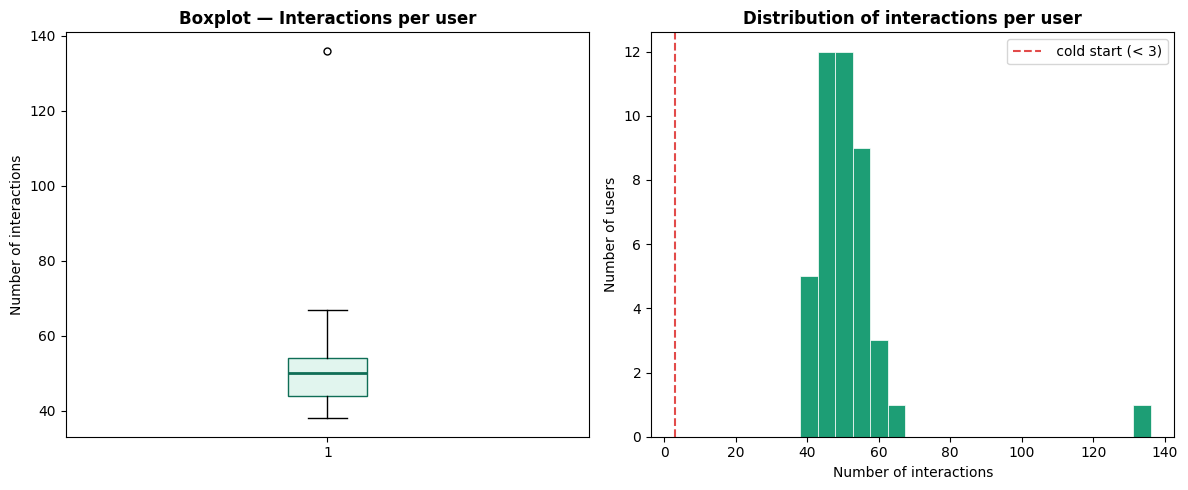

In [31]:
# -----------------------------------------------------------------------------
# Création d'une figure avec 2 graphiques (boxplot + histogramme)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------------------------------------------------------
# CALCUL DU NOMBRE D'INTERACTIONS PAR UTILISATEUR
# -----------------------------------------------------------------------------

# Regrouper les données par utilisateur et compter le nombre d'interactions
user_counts = interactions.groupby('user_id').size()

# -----------------------------------------------------------------------------
# BOXPLOT DES INTERACTIONS PAR UTILISATEUR
# -----------------------------------------------------------------------------

# Création du boxplot avec personnalisation
axes[0].boxplot(user_counts, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#E1F5EE', color='#0F6E56'),  # couleur de la boîte
                medianprops=dict(color='#0F6E56', linewidth=2),        # ligne de médiane
                flierprops=dict(marker='o', color='#E24B4A', markersize=5))  # outliers

# Titre du graphique
axes[0].set_title('Boxplot — Interactions per user', fontweight='bold')

# Nom de l’axe Y
axes[0].set_ylabel('Number of interactions')

# -----------------------------------------------------------------------------
# STATISTIQUES IMPORTANTES
# -----------------------------------------------------------------------------

# Affichage des statistiques principales dans la console
print(f"\nInteractions per user :")

# Médiane (valeur centrale)
print(f"  Mediane : {user_counts.median():.0f}")

# Quartiles Q1 et Q3
print(f"  Q1 : {user_counts.quantile(0.25):.0f}  |  Q3 : {user_counts.quantile(0.75):.0f}")

# Valeurs minimale et maximale
print(f"  Min : {user_counts.min()}  |  Max : {user_counts.max()}")

# Détection des utilisateurs avec peu d'interactions (cold start)
print(f"  Users with < 3 interactions (cold start) : "
      f"{(user_counts < 3).sum()} ({(user_counts < 3).mean():.1%})")

# -----------------------------------------------------------------------------
# HISTOGRAMME DES INTERACTIONS
# -----------------------------------------------------------------------------

# Création de l’histogramme
axes[1].hist(user_counts, bins=20,
             color='#1D9E75', edgecolor='white', linewidth=0.5)

# Ligne verticale pour le seuil cold start (< 3 interactions)
axes[1].axvline(3, color='#E24B4A', linestyle='--', linewidth=1.5,
                label=' cold start (< 3)')

# Titre du graphique
axes[1].set_title('Distribution of interactions per user', fontweight='bold')

# Nom de l’axe X
axes[1].set_xlabel('Number of interactions')

# Nom de l’axe Y
axes[1].set_ylabel('Number of users')

# Affichage de la légende
axes[1].legend()

# -----------------------------------------------------------------------------
# AJUSTEMENT ET SAUVEGARDE
# -----------------------------------------------------------------------------

# Ajustement automatique de l’espace entre les graphiques
plt.tight_layout()

# Sauvegarde de la figure
plt.savefig('fig3_interactions_users.png', dpi=150, bbox_inches='tight')

# Affichage final
plt.show()

Distribution des actions

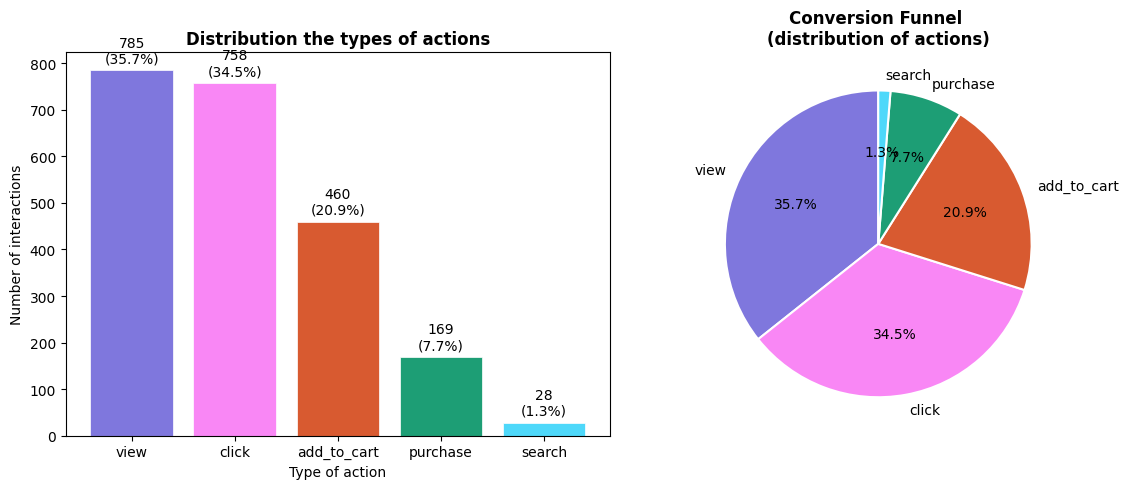

In [13]:
# -----------------------------------------------------------------------------
# Création d'une figure avec deux graphiques (barplot + camembert)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------------------------------------------------------
# CALCUL DU NOMBRE D'INTERACTIONS PAR TYPE D'ACTION
# -----------------------------------------------------------------------------

# Compter le nombre de chaque type d'action (view, add_to_cart, purchase)
action_counts = interactions['action'].value_counts()

# -----------------------------------------------------------------------------
# PERSONNALISATION DES COULEURS
# -----------------------------------------------------------------------------

# Dictionnaire de couleurs pour chaque type d'action
colors = {'search':"#4ED8FA",'view':'#7F77DD','click':"#F987F5",
                 'add_to_cart':'#D85A30','purchase':'#1D9E75'}

# Associer une couleur à chaque action (avec une couleur par défaut si inconnue)
bar_colors = [colors.get(a, '#888780') for a in action_counts.index]

# -----------------------------------------------------------------------------
# BARPLOT DES INTERACTIONS
# -----------------------------------------------------------------------------

# Création du diagramme en barres
bars = axes[0].bar(action_counts.index, action_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=0.5)

# Ajouter les valeurs et pourcentages au-dessus de chaque barre
for bar, val in zip(bars, action_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,  # position X (centre de la barre)
                 bar.get_height() + 10,             # position Y (au-dessus de la barre)
                 f'{val}\n({val/len(interactions):.1%})',  # valeur + pourcentage
                 ha='center', va='bottom', fontsize=10)

# Titre du graphique
axes[0].set_title('Distribution the types of actions', fontweight='bold')

# Nom de l’axe X
axes[0].set_xlabel('Type of action')

# Nom de l’axe Y
axes[0].set_ylabel('Number of interactions')



# Création du graphique en camembert pour montrer la répartition des actions
axes[1].pie(action_counts.values,
            labels=action_counts.index,
            colors=bar_colors,
            autopct='%1.1f%%',       # affichage du pourcentage
            startangle=90,           # rotation pour meilleure lisibilité
            wedgeprops=dict(edgecolor='white', linewidth=1.5))  # bordures

# Titre du camembert
axes[1].set_title('Conversion Funnel \n(distribution of actions)', fontweight='bold')


# Ajustement automatique de l’espace entre les graphiques
plt.tight_layout()

# Sauvegarde de la visualisation
plt.savefig('fig4_actions.png', dpi=150, bbox_inches='tight')

# Affichage final
plt.show()



 Distribution des profils santé

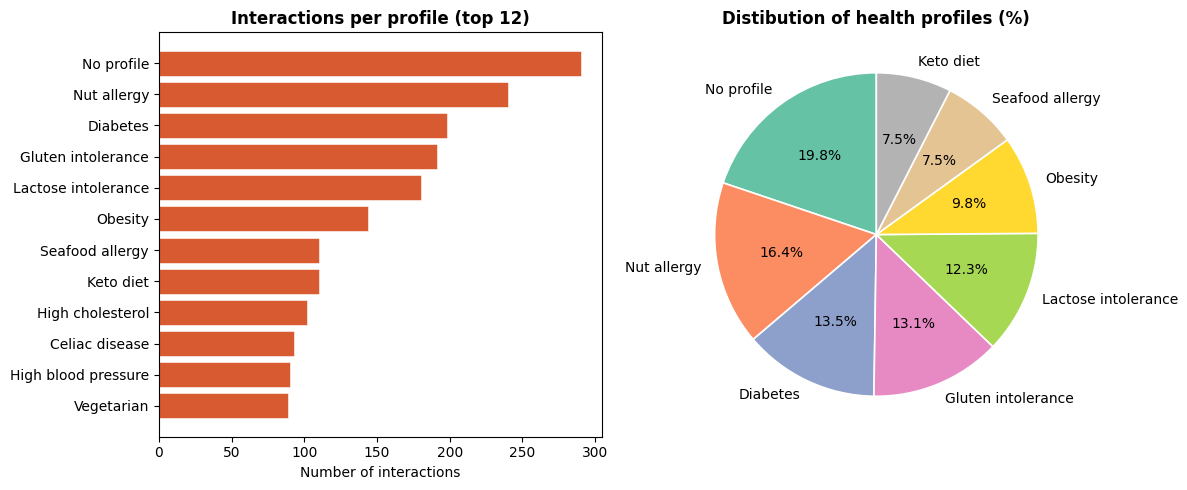


NaN health_profile : 290 (13.2%)
Profils distincts  : 18


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
hp = interactions['health_profile'].fillna('No profile')
hp_primary = hp.str.split(',').apply(lambda x: x[0].strip())
hp_counts  = hp.value_counts().head(12)
hp_simple  = hp_primary.value_counts()

# Barplot
axes[0].barh(hp_counts.index[::-1], hp_counts.values[::-1],
             color='#D85A30', edgecolor='white', linewidth=0.4)
axes[0].set_title('Interactions per profile (top 12)', fontweight='bold')
axes[0].set_xlabel('Number of interactions')
 
# Proportion en camembert
axes[1].pie(hp_simple.values[:8], labels=hp_simple.index[:8],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2', 8),
            wedgeprops=dict(edgecolor='white', linewidth=1.2))
axes[1].set_title('Distibution of health profiles (%)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_health_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nNaN health_profile : {interactions['health_profile'].isna().sum()} "
      f"({interactions['health_profile'].isna().mean():.1%})")
print(f"Profils distincts  : {interactions['health_profile'].nunique()}")

Distribution par heure et par saison 

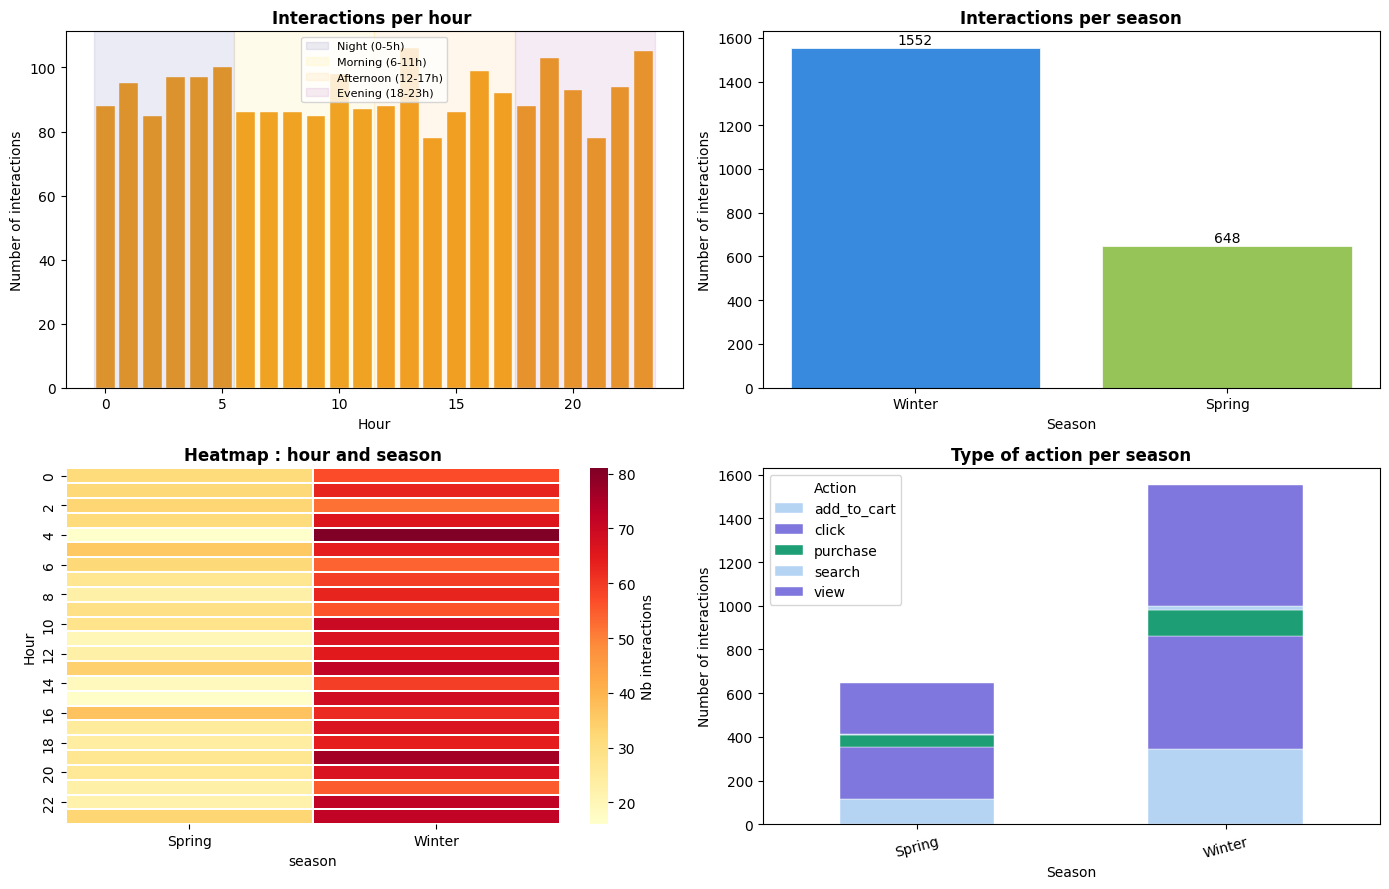


Heure de pic d'activité : 13h (106 interactions)
Valide la feature H_i : les interactions ne sont PAS uniformes sur 24h
Peak saison : Winter (1552 interactions)


In [29]:
# Crée une figure 2x2 pour les différentes visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Nombre d'interactions par heure ---
# Compte le nombre d'interactions pour chaque heure
hour_counts = interactions.groupby('hour').size()
# Trace un barplot des interactions par heure
axes[0, 0].bar(hour_counts.index, hour_counts.values,
               color='#EF9F27', edgecolor='white', linewidth=0.3)

# Ajoute des zones colorées pour visualiser les périodes de la journée
axes[0, 0].axvspan(-0.5, 5.5, alpha=0.08, color='navy',  label='Night (0-5h)')
axes[0, 0].axvspan(5.5,  11.5, alpha=0.08, color='gold',  label='Morning (6-11h)')
axes[0, 0].axvspan(11.5, 17.5, alpha=0.08, color='orange',label='Afternoon (12-17h)')
axes[0, 0].axvspan(17.5, 23.5, alpha=0.08, color='purple',label='Evening (18-23h)')

# Titres et labels
axes[0, 0].set_title('Interactions per hour ', fontweight='bold')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Number of interactions')
axes[0, 0].legend(fontsize=8)

#Nombre d'interactions par saison ---
# Compte le nombre d'interactions par saison
season_counts = interactions['season'].value_counts()
# Associe une couleur à chaque saison
season_colors = {'Winter':'#378ADD','Spring':'#97C459',
            'Summer':'#EF9F27','Autumn':'#D85A30'}

bar_c = [season_colors.get(s, '#888') for s in season_counts.index]

# Trace le barplot des interactions par saison
axes[0, 1].bar(season_counts.index, season_counts.values,
               color=bar_c, edgecolor='white', linewidth=0.5)

# Ajoute les valeurs au-dessus de chaque barre
for bar, val in zip(axes[0, 1].patches, season_counts.values):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                    str(val), ha='center', va='bottom', fontsize=10)

# Titres et labels
axes[0, 1].set_title('Interactions per season', fontweight='bold')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Number of interactions')

# Heatmap heure × saison ---
# Crée un tableau croisé heure × saison pour le heatmap
hour_season = interactions.groupby(['hour', 'season']).size().unstack(fill_value=0)
# Trace le heatmap avec dégradé jaune → rouge
sns.heatmap(hour_season, ax=axes[1, 0], cmap='YlOrRd',
            linewidths=0.3, cbar_kws={'label': 'Nb interactions'})

# Titres et labels du heatmap
axes[1, 0].set_title('Heatmap : hour and season', fontweight='bold')
axes[1, 0].set_xlabel('season')
axes[1, 0].set_ylabel('Hour')

# --- 6d : Type d'action par saison (stacked barplot) ---
# Regroupe par saison et type d'action
action_season = interactions.groupby(['season', 'action']).size().unstack(fill_value=0)
# Trace un barplot empilé
action_season.plot(kind='bar', ax=axes[1, 1], stacked=True,
                   color=['#B5D4F4', '#7F77DD', '#1D9E75'],
                   edgecolor='white', linewidth=0.3)

# Titres et labels
axes[1, 1].set_title('Type of action per season', fontweight='bold')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Number of interactions')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend(title='Action')

# Ajuste l'espacement et affiche la figure
plt.tight_layout()
plt.savefig('fig6_hour_season.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Interprétation automatique (print en anglais) ---
peak_hour = hour_counts.idxmax()
print(f"\nHeure de pic d'activité : {peak_hour}h ({hour_counts.max()} interactions)")
print(f"Valide la feature H_i : les interactions ne sont PAS uniformes sur 24h")
print(f"Peak saison : {season_counts.idxmax()} ({season_counts.max()} interactions)")


Analyse de la sparsité


User-item matrix: 43 users × 240 products
Filled cells : 2176 / 10320 (21.1%)
Sparsity : 78.9%
→ 79% sparsity → justifies the hybrid approach


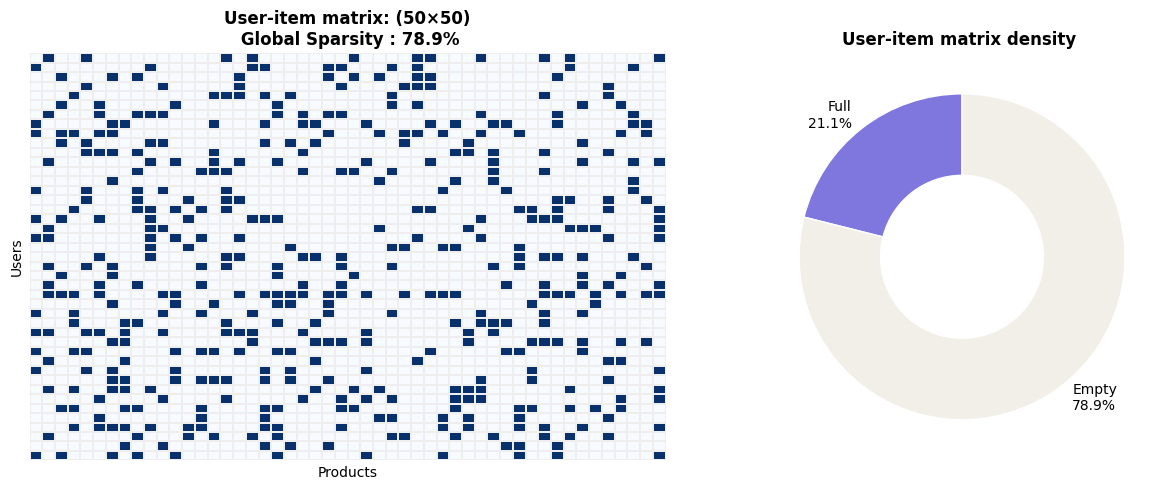

In [16]:
# Crée une figure 1x2 pour visualiser la matrice user-item et la sparsité
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Construction de la matrice user-item ---
# Pivot table : lignes = users, colonnes = produits, valeurs = nombre d'actions
user_item = interactions.pivot_table(
    index='user_id', columns='product_id',
    values='action_score', aggfunc='count', fill_value=0
)

# Nombre d'utilisateurs et de produits
nb_users    = user_item.shape[0]
nb_products = user_item.shape[1]
nb_total    = nb_users * nb_products

# Nombre de cellules remplies (où user a interagi avec produit)
nb_filled   = (user_item > 0).sum().sum()

# Calcul de la sparsité (1 = très sparse, 0 = matrice dense)
sparsité    = 1 - nb_filled / nb_total

# --- Print en anglais pour l'interprétation ---
print(f"\nUser-item matrix: {nb_users} users × {nb_products} products")
print(f"Filled cells : {nb_filled} / {nb_total} ({1 - sparsité:.1%})")
print(f"Sparsity : {sparsité:.1%}")
print(f"→ {sparsité:.0%} sparsity → justifies the hybrid approach")


# --- Visualisation de la sparsité (heatmap échantillon 50×50) ---
# On prend les 50 premiers users et produits pour visualiser
sample_matrix = (user_item.iloc[:50, :50] > 0).astype(int)

# Heatmap : bleu = interaction, blanc = pas d'interaction
sns.heatmap(sample_matrix, ax=axes[0], cmap='Blues',
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.1, linecolor='#eee')

axes[0].set_title(f'User-item matrix: (50×50)\n Global Sparsity : {sparsité:.1%}',
                  fontweight='bold')
axes[0].set_xlabel('Products')
axes[0].set_ylabel('Users')

# --- Donut chart pour montrer densité globale ---
sizes  = [nb_filled, nb_total - nb_filled]  # Remplies vs vides
labels = [f'Full\n{1-sparsité:.1%}', f'Empty\n{sparsité:.1%}']

axes[1].pie(sizes, labels=labels, colors=['#7F77DD', '#F1EFE8'],
            startangle=90, wedgeprops=dict(width=0.5, edgecolor='white'))
axes[1].set_title('User-item matrix density ', fontweight='bold')

# Ajuste l'espacement et affiche la figure
plt.tight_layout()
plt.savefig('fig7_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()

Top produits les plus popilaires

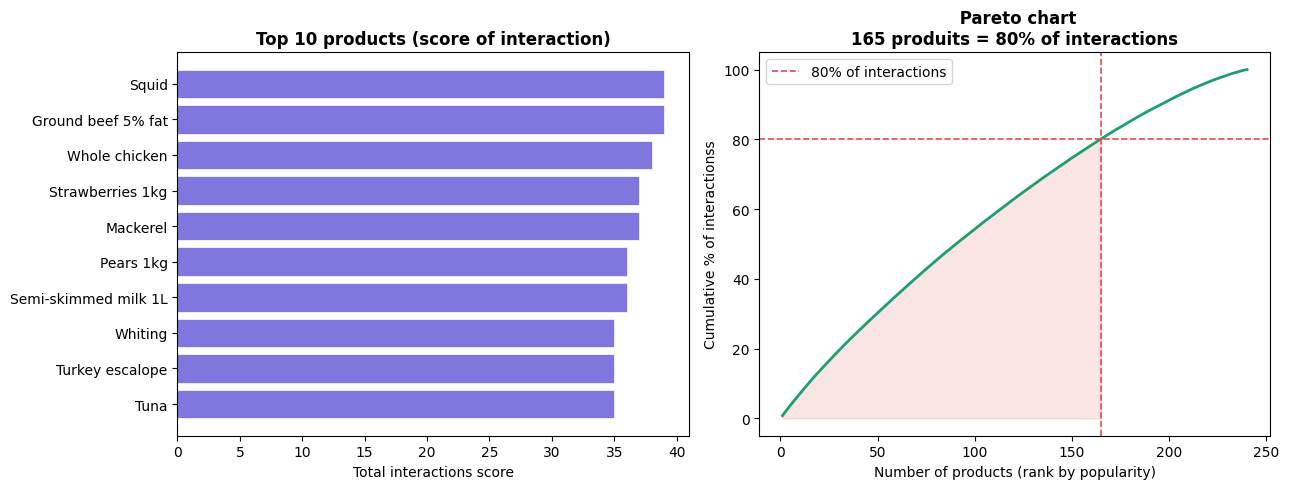


165 produits sur 240 concentrent 80% des interactions (effet Pareto)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
pop = interactions.groupby('product_id')['action_score'].sum()\
                  .sort_values(ascending=False)
 
# Fusionne avec le nom du produit
pop_named = pop.reset_index().merge(
    interactions[['product_id','product_name']].drop_duplicates(),
    on='product_id', how='left')
pop_named['label'] = pop_named['product_name'].str[:22]  # tronque les noms longs
 
# Top 10
top10 = pop_named.head(10)
axes[0].barh(top10['label'][::-1], top10['action_score'][::-1],
             color='#7F77DD', edgecolor='white', linewidth=0.5)
axes[0].set_title('Top 10 products (score of interaction)', fontweight='bold')
axes[0].set_xlabel('Total interactions score')
 
# Courbe de Pareto — effet longue traîne
cumul = pop.cumsum() / pop.sum() * 100
axes[1].plot(range(1, len(cumul) + 1), cumul.values,
             color='#1D9E75', linewidth=2)
axes[1].axhline(80, color='#E24B4A', linestyle='--', linewidth=1.2,
                label='80% of interactions')
# Trouve le nb de produits qui concentrent 80% des interactions
n_80 = (cumul < 80).sum() + 1
axes[1].axvline(n_80, color='#E24B4A', linestyle='--', linewidth=1.2)
axes[1].fill_between(range(1, n_80 + 1),
                     cumul.values[:n_80], alpha=0.15, color='#E24B4A')
axes[1].set_title(f' Pareto chart\n{n_80} produits = 80% of interactions',
                  fontweight='bold')
axes[1].set_xlabel('Number of products (rank by popularity)')
axes[1].set_ylabel('Cumulative % of interactionss')
axes[1].legend()
 
plt.tight_layout()
plt.savefig('fig8_popularite.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n{n_80} produits sur {len(pop)} concentrent 80% des interactions (effet Pareto)")


 Distribution de la DLC 

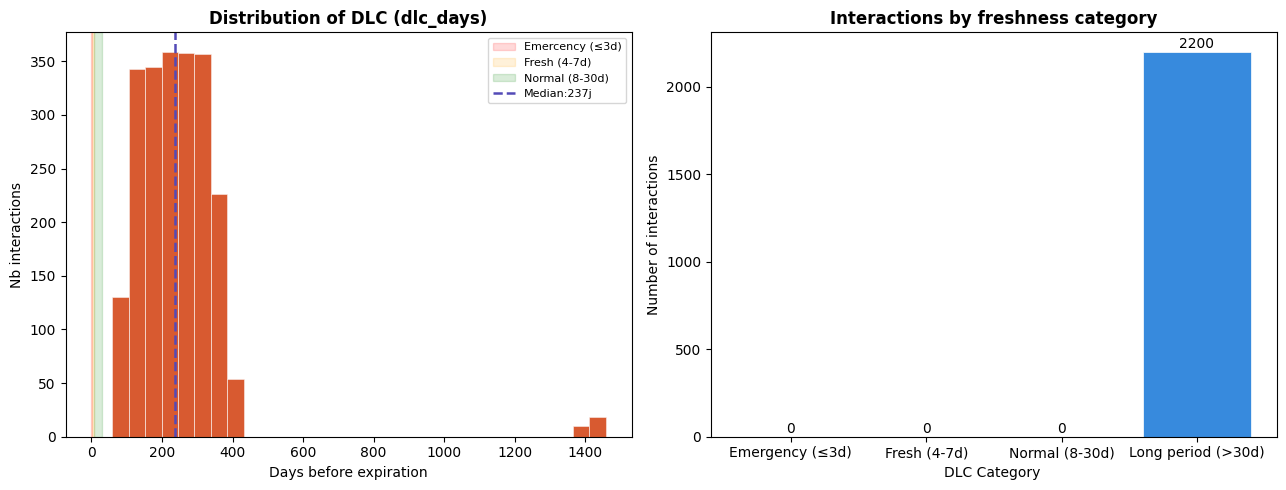


0.0% des interactions concernent des produits à DLC urgente (≤3j)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
dlc = interactions['dlc_days']
 
# Histogramme
axes[0].hist(dlc, bins=30, color='#D85A30', edgecolor='white', linewidth=0.4)

# Zones DLC colorées
axes[0].hist(dlc, bins=30, color='#D85A30', edgecolor='white', linewidth=0.4)
for span, color, lbl in [
        ((0,3),'red','Emercency (≤3d)'),
        ((3,7),'orange','Fresh (4-7d)'),
        ((7,30),'green','Normal (8-30d)')]:
    axes[0].axvspan(span[0], span[1], alpha=0.15, color=color, label=lbl)
axes[0].axvline(dlc.median(), color='#534AB7', linestyle='--',
                linewidth=1.8, label=f'Median:{dlc.median():.0f}j')
axes[0].set_title('Distribution of DLC (dlc_days)', fontweight='bold')
axes[0].set_xlabel('Days before expiration')
axes[0].set_ylabel('Nb interactions')
axes[0].legend(fontsize=8)

 
# Répartition par catégorie de fraîcheur
dlc_cats = pd.cut(dlc, bins=[0, 3, 7, 30, 9999],
                  labels=['Emergency (≤3d)', 'Fresh (4-7d)',
                          'Normal (8-30d)', 'Long period (>30d)'])
dlc_c = dlc_cats.value_counts().sort_index()
axes[1].bar(dlc_c.index, dlc_c.values,
            color=['#E24B4A','#EF9F27','#1D9E75','#378ADD'],
            edgecolor='white', linewidth=0.5)
for bar, val in zip(axes[1].patches, dlc_c.values):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+5, str(val),
                 ha='center', va='bottom', fontsize=10)
axes[1].set_title('Interactions by freshness category', fontweight='bold')
axes[1].set_xlabel('DLC Category ')
axes[1].set_ylabel('Number of interactions')

 
plt.tight_layout()
plt.savefig('fig9_dlc.png', dpi=150, bbox_inches='tight')
plt.show()
 
pct_urgent = (dlc <= 3).mean() * 100
print(f"\n{pct_urgent:.1f}% des interactions concernent des produits à DLC urgente (≤3j)")

Diversité des ingrédients (justifie TF-IDF)

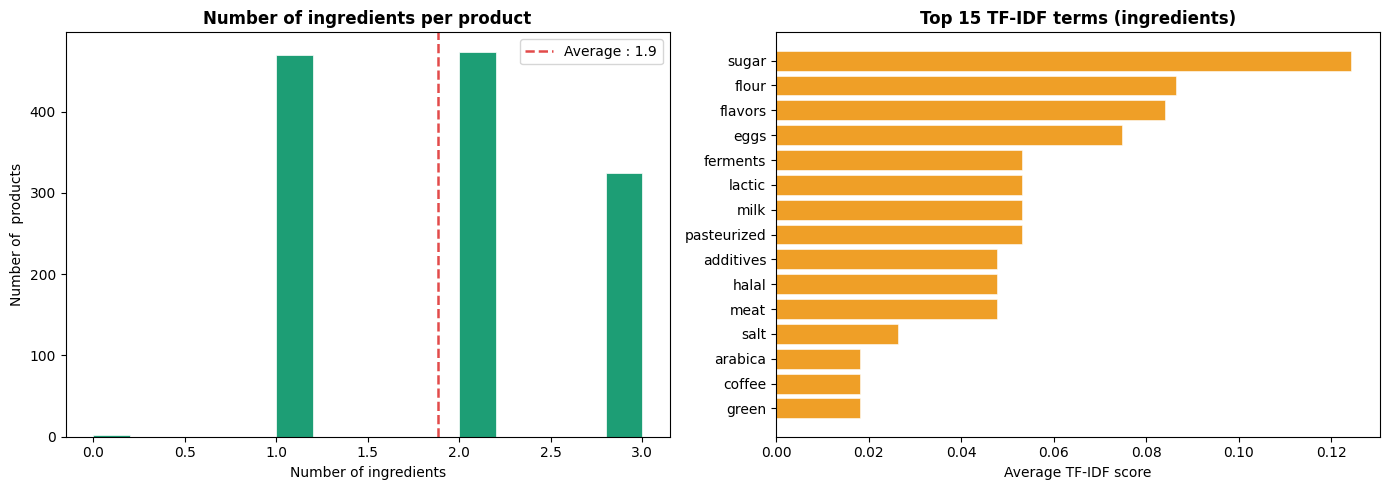


Ingredients uniques    : 13
Longueur moyenne       : 1.9 par produit

Allergens — 2 NaN 


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
products = products.rename(columns={'Ingredients vary by product': 'ingredients'})
# ── Histogramme : nombre d'ingrédients par produit ──────────────
products['nb_ingredients'] = (
    products['ingredients']
    .fillna('')
    .astype(str)
    .str.split(r'\.\s*')           
    .apply(lambda x: len([i for i in x if i.strip() and len(i.strip()) > 1]))
)

axes[0].hist(products['nb_ingredients'], bins=15,
            color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[0].axvline(products['nb_ingredients'].mean(),
               color='#E24B4A', linestyle='--', linewidth=1.8,
               label=f"Average : {products['nb_ingredients'].mean():.1f}")
# ^ axvline ajoute une ligne verticale à la moyenne
axes[0].set_title('Number of ingredients per product', fontweight='bold')
axes[0].set_xlabel('Number of ingredients')
axes[0].set_ylabel('Number of  products')
axes[0].legend()

# ── TF-IDF : vrais scores moyens 


# --- Section Diversité des ingrédients (version corrigée) ---

# 1. Nettoyage ciblé : on garde la structure mais on enlève le "bruit"
ings_clean = (
    products['ingredients']
    .fillna('')
    .str.lower()
    .str.replace(r'\b(fresh|no|preservatives|added|natural|vary|product|by)\b', '', regex=True)
    .str.strip()
)

# 2. Configuration du Vectorizer
custom_stopwords = [
    'ingredients', 'contains', 'water', 'and', 'with',
    'products', 'daily', 'catch', 'added'  ,'100'
]
tfidf_viz = TfidfVectorizer(
    stop_words=custom_stopwords, # Utiliser le paramètre stop_words explicitement
    max_features=15,
    ngram_range=(1, 1),          # <--- ICI : (1,1) pour éviter "flour eggs"
    min_df=2
)

X = tfidf_viz.fit_transform(ings_clean)
# ... le reste de votre code pour l'affichage ...

X = tfidf_viz.fit_transform(ings_clean)
scores = X.mean(axis=0).A1
# ^ moyenne du score TF-IDF de chaque terme sur tous les produits
#   .A1 : convertit la matrice numpy en tableau 1D

terms = tfidf_viz.get_feature_names_out()
# ^ récupère les noms des termes dans l'ordre des colonnes

# Trie par score décroissant et prépare les données du graphique
top = sorted(zip(terms, scores), key=lambda x: x[1], reverse=True)
# ^ zip associe chaque terme à son score, sorted trie du plus au moins fort

labels = [t[0] for t in top]   # noms des termes (ordre décroissant)
values = [t[1] for t in top]   # scores TF-IDF moyens correspondants

axes[1].barh(labels[::-1], values[::-1],
            # ^ [::-1] inverse pour mettre le meilleur en haut du graphique
            color='#EF9F27', edgecolor='white', linewidth=0.4)
axes[1].set_title('Top 15 TF-IDF terms (ingredients)', fontweight='bold')
axes[1].set_xlabel('Average TF-IDF score')
# ^ axe X = vrais scores TF-IDF (pas un rang arbitraire)

plt.tight_layout()
plt.savefig('fig10_ingredients.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistiques textuelles ──────────────────────────────────────
nb_unique = (
    products['ingredients']
    .str.lower()
    .str.split(',')
    .explode()        # une ligne par ingrédient
    .str.strip()       # supprime les espaces
    .nunique()         # compte les valeurs uniques
)
print(f"\nIngredients uniques    : {nb_unique}")
print(f"Longueur moyenne       : {products['nb_ingredients'].mean():.1f} par produit")

print(f"\nAllergens — {products['allergens'].isna().sum()} NaN ")
      